In [42]:
import os
import linecache
from pathlib import Path
import pandas as pd
import networkx as nx

In [20]:
file_path = os.path.abspath(Path('..', '.data', 'moongnd-8', 'moongnd_0 Contact Analysis.csv'))
file_path_as_str = str(file_path)
file_path_as_str

'/Users/dev.dabke/Documents/research/code/research/sumgraph/.data/moongnd-8/moongnd_0 Contact Analysis.csv'

In [3]:
# Certain lines of the original file cannot be parsed, so we handle them
# specifically and skip them when importing through pandas:
#   0: the header row that defines the file
#   1: the row that gives the timestamp of when the data is for
#   2: a blank line
#   3: the row that gives the timestamp of when the data was generated
#   4: the start and stop time of the simulation
#   6: the line that defines what units the data is in
skip_rows = [0, 1, 2, 3, 4, 6]

In [7]:
header_row = linecache.getline(
    filename=file_path_as_str, lineno=0 + 1
)  # lineno indexing begins at 1, not 0

In [36]:
df = pd.read_csv(  # type: ignore
    filepath_or_buffer=file_path_as_str, skiprows=skip_rows
).iloc[:, :-1]

In [40]:
df[['Source', 'Sink']] = df.Analysis.str.split(pat=' - ', n=2, expand=True)
df_final = df[['Source', 'Sink', 'Rise', 'Set']]

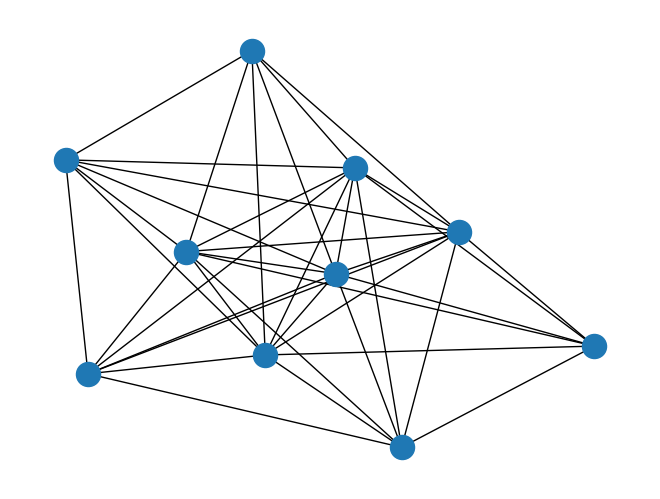

In [44]:
G = nx.from_pandas_edgelist(df=df_final, source='Source', target='Sink', edge_attr=['Rise', 'Set'])
nx.draw(G)

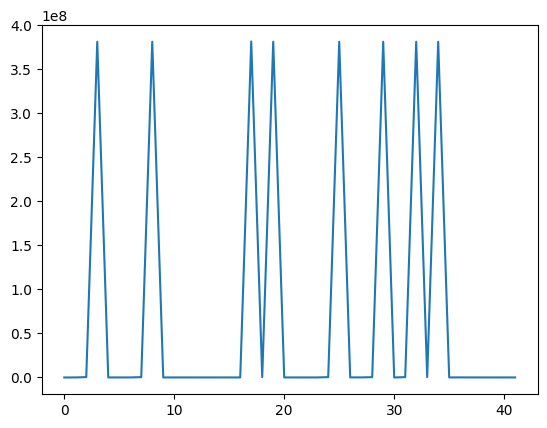

In [45]:
from matplotlib import pyplot
dat = [0.000,40530.0343,398443.6604,381244795.1069,38139.7329,47638.1783,47425.8985,390680.1321,381248901.8095,39934.7372,41091.3487,43607.8720,46622.9528,38139.0700,48263.9223,47724.9327,38881.3014,381535058.9586,389569.7416,381249278.4291,42905.2464,38556.1315,40608.9677,47658.4222,402817.8267,381267374.2323,76495.5350,82996.8236,359304.0761,381256519.0456,21746.3281,376325.9820,381235149.2259,434573.6868,381205927.6715,64416.0443,76470.3141,64747.9089,40667.9853,40122.0734,42755.6073,47112.9019]

pyplot.plot(dat)